In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

backtest_returns = pd.read_csv("../data/processed/backtest_returns.csv", index_col=0, parse_dates=True)

backtest_returns.head()

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark
2016-01-05,0.002666,-0.000240,-0.001736,0.001293,0.001691
2016-01-06,-0.004106,0.002448,-0.009611,0.000425,-0.012614
2016-01-07,-0.015195,-0.006126,-0.031331,-0.009636,-0.023992
2016-01-08,-0.008812,-0.004806,-0.008110,-0.006158,-0.010977
2016-01-11,-0.001462,-0.006157,0.003078,-0.003878,0.000990


In [2]:
trading_days = 252
risk_free_rate = 0.02

def annualized_return(returns):
    return returns.mean() * trading_days

def annualized_volatility(returns):
    return returns.std() * np.sqrt(trading_days)

def sharpe_ratio(returns, risk_free_rate=0.02):
    return (annualized_return(returns) - risk_free_rate) / annualized_volatility(returns)

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()

def historical_var(returns, confidence_level=0.95):
    return returns.quantile(1 - confidence_level)

def historical_cvar(returns, confidence_level=0.95):
    var = historical_var(returns, confidence_level)
    return returns[returns <= var].mean()

In [3]:
risk_metrics = pd.DataFrame(index=backtest_returns.columns)

risk_metrics["Annualized Return"] = backtest_returns.apply(annualized_return)
risk_metrics["Annualized Volatility"] = backtest_returns.apply(annualized_volatility)
risk_metrics["Sharpe Ratio"] = backtest_returns.apply(sharpe_ratio)
risk_metrics["Maximum Drawdown"] = backtest_returns.apply(max_drawdown)
risk_metrics["95% Historical VaR"] = backtest_returns.apply(historical_var)
risk_metrics["95% Historical CVaR"] = backtest_returns.apply(historical_cvar)

risk_metrics

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,95% Historical VaR,95% Historical CVaR
Equal Weight,0.097016,0.134932,0.570779,-0.275823,-0.012315,-0.019932
Minimum Variance,0.071141,0.098525,0.519069,-0.272702,-0.009371,-0.014188
Maximum Sharpe,0.091178,0.152204,0.467649,-0.287583,-0.015200,-0.023127
Risk Parity,0.093681,0.113890,0.646951,-0.269734,-0.010636,-0.016962
SPY Benchmark,0.140472,0.181049,0.665409,-0.341047,-0.016924,-0.027828


In [4]:
risk_metrics.to_csv("../data/processed/risk_metrics.csv")

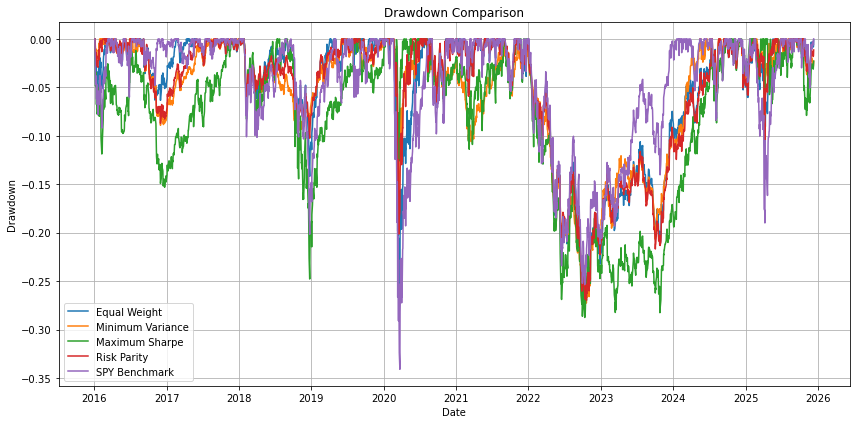

In [5]:
cumulative_returns = (1 + backtest_returns).cumprod()
running_max = cumulative_returns.cummax()
drawdowns = cumulative_returns / running_max - 1

plt.figure(figsize=(12, 6))

x = drawdowns.index.to_numpy()

for column in drawdowns.columns:
    y = drawdowns[column].to_numpy()
    plt.plot(x, y, label=column)

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/drawdown_comparison.png", dpi=300)
plt.show()

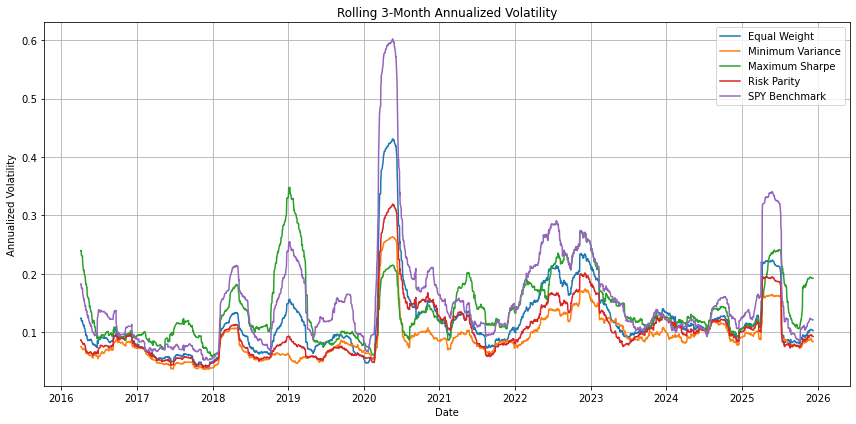

In [6]:
rolling_volatility = backtest_returns.rolling(window=63).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))

x = rolling_volatility.index.to_numpy()

for column in rolling_volatility.columns:
    y = rolling_volatility[column].to_numpy()
    plt.plot(x, y, label=column)

plt.title("Rolling 3-Month Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/rolling_volatility.png", dpi=300)
plt.show()

## Risk Analysis Interpretation

The risk analysis shows that the SPY benchmark achieved the highest annualized return and the highest Sharpe ratio, but it also experienced the largest downside risk. Its maximum drawdown reached around 34%, and its 95% historical CVaR was the most negative among all strategies.

Among the portfolio construction methods, the risk parity strategy delivered the strongest risk-adjusted performance, with a Sharpe ratio close to the SPY benchmark but lower volatility, smaller drawdown, and less severe tail losses. The minimum variance strategy achieved the lowest volatility and the smallest downside tail risk, although this came at the cost of lower annualized returns.

These results suggest that portfolio optimization methods may not always outperform a strong equity benchmark in terms of raw return, but they can improve risk control and downside protection. This is especially relevant from a risk management perspective.